In [13]:
! pip install requests opencv-python pillow numpy


[notice] A new release of pip is available: 24.0 -> 25.2
[notice] To update, run: pip install --upgrade pip


In [1]:
import base64
import requests
import json
import cv2
from os.path import join
import numpy as np
from io import BytesIO

base_endpoint = "http://localhost:8000"
headers = {}

In [2]:
def draw_face(img, bbox, label):
    cv2.rectangle(img, (int(bbox[0]), int(bbox[1])), (int(bbox[2]), int(bbox[3])), (255,0,0), 2)
    cv2.putText(img, label, (int(bbox[0])+5, int(bbox[1])+25), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 0), 2)
    return img

In [3]:
SRC_PATH = "../tests/assets"

# Object Detection

In [9]:
endpoint = f"{base_endpoint}/v1/forward"
img_file = join(SRC_PATH, "image.jpg")

img_base64 = base64.b64encode(open(img_file, "rb").read()).decode()
body = {
    "image": img_base64,
}

res = requests.post(
    endpoint,
    json=body,
    timeout=10,
    headers=headers
)

if res.status_code==200:
    print(json.dumps(res.json(), indent=4, sort_keys=True))
else:
    print(res.status_code)
    print(json.dumps(res.json(), indent=4, sort_keys=True))

{
    "detections": [
        {
            "bbox": [
                32.851715087890625,
                104.19832611083984,
                226.03036499023438,
                429.27825927734375
            ],
            "label": "person",
            "score": 0.9015095829963684
        },
        {
            "bbox": [
                296.334228515625,
                177.9844207763672,
                409.01397705078125,
                419.3150329589844
            ],
            "label": "person",
            "score": 0.8500510454177856
        },
        {
            "bbox": [
                216.93853759765625,
                185.87258911132812,
                307.6229248046875,
                426.7506103515625
            ],
            "label": "person",
            "score": 0.8253358006477356
        },
        {
            "bbox": [
                57.456607818603516,
                356.61865234375,
                100.41064453125,
                376.2546691894531


## Show image with detected objects

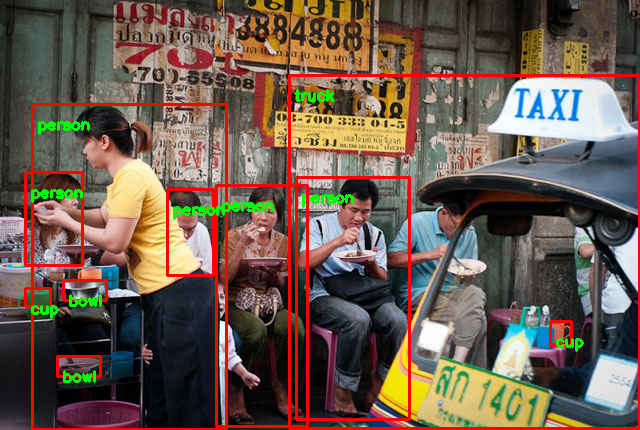

In [10]:
from PIL import Image

img_data = base64.b64decode(str(img_base64))
img = Image.open(BytesIO(img_data)).convert("RGB")

img = np.array(img)
objs = res.json()["detections"]

for obj in objs:
    bbox = obj["bbox"]
    label = obj["label"]
    # score = obj["score"]
    img = draw_face(img, bbox, label)

Image.fromarray(img).convert('RGB')